# 1.2 ML Model
Reads the processed CSVs from the ETL, trains a Logistic Regression pipeline, evaluates it, and exports the model as a `.joblib` file for the Streamlit web app.

In [41]:
"""
1.2 ML Model — Multi-Class Classification with Model Comparison
================================================================
- 4-class target (Big Fall, Small Fall, Small Rise, Big Rise)
- 5 models compared: Logistic Regression, Random Forest, 
  Gradient Boosting, XGBoost, Ensemble
- Hyperparameter tuning with GridSearchCV
- Best model exported for web app
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Feature columns (must match ETL output) ────────────────────────
FEATURE_COLS = [
    # Original
    "Returns", "SMA_5", "SMA_20", "Volatility_5", "Volatility_20",
    "Volume_Change", "RSI_14", "Price_Range",
    # New
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Width", "BB_Position",
    "Momentum_10", "Momentum_20",
    "ATR_Ratio",
    "Return_Lag1", "Return_Lag2", "Return_Lag3", "Return_Lag5",
    "Volume_Ratio",
    "DayOfWeek",
    "Dist_SMA_5", "Dist_SMA_20",
]

TARGET = "Target"

# ── Class labels for display ───────────────────────────────────────
CLASS_NAMES = ["Big Fall", "Small Fall", "Small Rise", "Big Rise"]

TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]

print("Setup complete!")

Setup complete!


## Step 1 — Load ETL output
Do NOT re-run ETL here. Just read the CSV the ETL already saved.

In [42]:
def load_data(ticker: str) -> tuple:
    """
    Load processed data and split into train/test sets.
    Uses time-based split (no shuffling) because this is financial data.
    
    Returns:
        X_train, X_test, y_train, y_test, full_dataframe
    """
    # Load
    path = f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv"
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Remove any remaining NaN
    df = df.dropna(subset=FEATURE_COLS + [TARGET])
    
    # Features and target
    X = df[FEATURE_COLS]
    y = df[TARGET].astype(int)
    
    # Time-based split: 70% train, 30% test (no shuffle!)
    split_idx = int(len(df) * 0.7)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Loaded {ticker}: {len(df)} rows")
    print(f"  Train: {len(X_train)} rows ({len(X_train)/len(df)*100:.0f}%)")
    print(f"  Test:  {len(X_test)} rows ({len(X_test)/len(df)*100:.0f}%)")
    print(f"  Class distribution in train: {dict(y_train.value_counts().sort_index())}")
    
    return X_train, X_test, y_train, y_test, df

# Test with one ticker
X_train, X_test, y_train, y_test, df = load_data("AMZN")

Loaded AMZN: 1217 rows
  Train: 851 rows (70%)
  Test:  366 rows (30%)
  Class distribution in train: {0: np.int64(245), 1: np.int64(169), 2: np.int64(178), 3: np.int64(259)}


# DEFINE MODELS

In [43]:
def get_models() -> dict:
    """Define all 5 models to compare."""
    
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="lbfgs",
                max_iter=1000,
                random_state=42
            ))
        ]),
        
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=10,
                random_state=42,
                n_jobs=-1
            ))
        ]),
        
        "Gradient Boosting": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GradientBoostingClassifier(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42
            ))
        ]),
        
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                use_label_encoder=False,
                eval_metric="mlogloss",
                verbosity=0
            ))
        ]),
    }

print("Models:", list(get_models().keys()))

Models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


# MODEL COMPARISON 

In [44]:
def compare_models(X_train, X_test, y_train, y_test) -> tuple:
    """Train and evaluate all models."""
    
    models = get_models()
    results = []
    trained_models = {}
    
    print("Training models...")
    print("-" * 60)
    
    for name, pipeline in models.items():
        # Train
        pipeline.fit(X_train, y_train)
        trained_models[name] = pipeline
        
        # Predict
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        
        try:
            auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
        except:
            auc = np.nan
        
        results.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "F1 Macro": round(f1, 4),
            "AUC": round(auc, 4) if not np.isnan(auc) else "N/A"
        })
        
        print(f"{name:25s} | Acc: {acc:.4f} | F1: {f1:.4f}")
    
    print("-" * 60)
    
    comparison_df = pd.DataFrame(results).sort_values("F1 Macro", ascending=False)
    return comparison_df, trained_models

# Run comparison
comparison, trained_models = compare_models(X_train, X_test, y_train, y_test)
comparison

Training models...
------------------------------------------------------------
Logistic Regression       | Acc: 0.2350 | F1: 0.2346
Random Forest             | Acc: 0.2459 | F1: 0.2302
Gradient Boosting         | Acc: 0.2596 | F1: 0.2554
XGBoost                   | Acc: 0.2432 | F1: 0.2351
------------------------------------------------------------


,Model,Accuracy,F1 Macro,AUC
2,Gradient Boosting,0.2596,0.2554,0.5018
3,XGBoost,0.2432,0.2351,0.5040
0,Logistic Regression,0.2350,0.2346,0.4882
1,Random Forest,0.2459,0.2302,0.5025


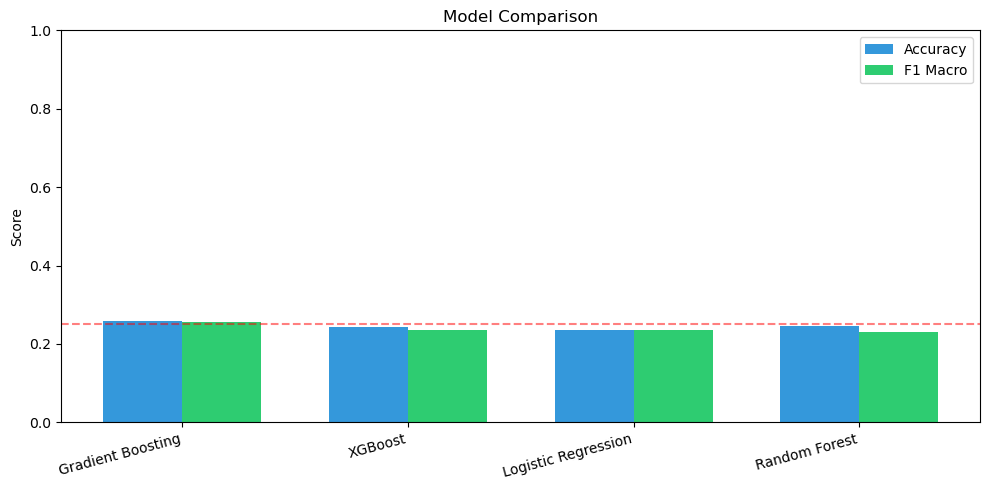

In [45]:
def plot_comparison(comparison_df):
    """Bar chart comparing models."""
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = range(len(comparison_df))
    width = 0.35
    
    bars1 = ax.bar([i - width/2 for i in x], comparison_df["Accuracy"], 
                   width, label="Accuracy", color="#3498db")
    bars2 = ax.bar([i + width/2 for i in x], comparison_df["F1 Macro"], 
                   width, label="F1 Macro", color="#2ecc71")
    
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.axhline(y=0.25, color="red", linestyle="--", alpha=0.5, label="Random baseline")
    
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/model_comparison.png", dpi=150)
    plt.show()

plot_comparison(comparison)

Best model: Gradient Boosting



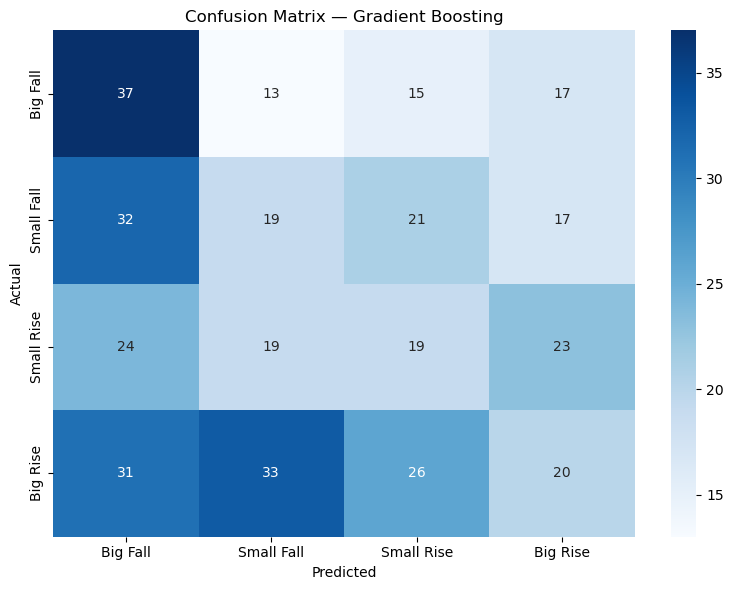

              precision    recall  f1-score   support

    Big Fall       0.30      0.45      0.36        82
  Small Fall       0.23      0.21      0.22        89
  Small Rise       0.23      0.22      0.23        85
    Big Rise       0.26      0.18      0.21       110

    accuracy                           0.26       366
   macro avg       0.25      0.27      0.26       366
weighted avg       0.25      0.26      0.25       366



In [46]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    """Plot confusion matrix."""
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Best model so far
best_name = comparison.iloc[0]["Model"]
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print(f"Best model: {best_name}\n")
plot_confusion_matrix(y_test, y_pred, best_name)

In [47]:
def tune_model(model_name: str, X_train, y_train):
    """Tune hyperparameters using GridSearchCV."""
    
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1, 10],
        },
        "Random Forest": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [5, 10, 15],
            "clf__min_samples_split": [5, 10],
        },
        "Gradient Boosting": {
            "clf__n_estimators": [100, 150],
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1],
        },
        "XGBoost": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [4, 6, 8],
            "clf__learning_rate": [0.05, 0.1],
        },
    }
    
    if model_name not in param_grids:
        return None, None, None
    
    pipeline = get_models()[model_name]
    param_grid = param_grids[model_name]
    
    print(f"Tuning {model_name}...")
    
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1:  {grid.best_score_:.4f}\n")
    
    return grid.best_estimator_, grid.best_params_, grid.best_score_

# Tune top 2 models
top_2 = comparison.head(2)["Model"].tolist()
tuned_models = {}

for name in top_2:
    best_pipe, best_params, best_score = tune_model(name, X_train, y_train)
    if best_pipe:
        tuned_models[name] = {
            "pipeline": best_pipe,
            "params": best_params,
            "cv_score": best_score
        }

Tuning Gradient Boosting...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 150}
  Best CV F1:  0.2473

Tuning XGBoost...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 100}
  Best CV F1:  0.2467



In [48]:
def evaluate_tuned(tuned_models, X_test, y_test):
    """Evaluate tuned models on test set."""
    
    results = []
    
    for name, data in tuned_models.items():
        pipeline = data["pipeline"]
        y_pred = pipeline.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        
        results.append({
            "Model": f"{name} (Tuned)",
            "Accuracy": round(acc, 4),
            "F1 Macro": round(f1, 4),
        })
        
        print(f"{name} (Tuned): Acc={acc:.4f}, F1={f1:.4f}")
    
    return pd.DataFrame(results)

tuned_results = evaluate_tuned(tuned_models, X_test, y_test)
tuned_results

Gradient Boosting (Tuned): Acc=0.2568, F1=0.2320
XGBoost (Tuned): Acc=0.2322, F1=0.2246


,Model,Accuracy,F1 Macro
0,Gradient Boosting (Tuned),0.2568,0.2320
1,XGBoost (Tuned),0.2322,0.2246


In [49]:
def create_ensemble(X_train, y_train, X_test, y_test):
    """Create voting ensemble of all models."""
    
    print("Creating Ensemble...")
    
    ensemble = VotingClassifier(
        estimators=[
            ("lr", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=1000, random_state=42))  # Fixed
            ])),
            ("rf", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42))
            ])),
            ("gb", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42))
            ])),
            ("xgb", Pipeline([
                ("scaler", StandardScaler()),
                ("clf", XGBClassifier(n_estimators=150, max_depth=6, random_state=42,
                                      use_label_encoder=False, eval_metric="mlogloss", verbosity=0))
            ])),
        ],
        voting="soft",
        n_jobs=-1
    )
    
    ensemble.fit(X_train, y_train)
    
    y_pred = ensemble.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    
    print(f"Ensemble: Acc={acc:.4f}, F1={f1:.4f}")
    
    return ensemble, {"Accuracy": acc, "F1 Macro": f1}

ensemble, ensemble_metrics = create_ensemble(X_train, y_train, X_test, y_test)

Creating Ensemble...
Ensemble: Acc=0.2404, F1=0.2328


In [50]:
def select_and_export(ticker, trained_models, tuned_models, ensemble, ensemble_metrics, X_test, y_test):
    """Compare all models and export the best one."""
    
    print(f"\n{'='*50}")
    print(f"FINAL SELECTION — {ticker}")
    print(f"{'='*50}\n")
    
    candidates = []
    
    # Base models
    for name, pipeline in trained_models.items():
        y_pred = pipeline.predict(X_test)
        f1 = f1_score(y_test, y_pred, average="macro")
        candidates.append({"name": name, "pipeline": pipeline, "f1": f1, "type": "Base"})
    
    # Tuned models
    for name, data in tuned_models.items():
        y_pred = data["pipeline"].predict(X_test)
        f1 = f1_score(y_test, y_pred, average="macro")
        candidates.append({"name": f"{name} (Tuned)", "pipeline": data["pipeline"], "f1": f1, "type": "Tuned"})
    
    # Ensemble
    candidates.append({"name": "Ensemble", "pipeline": ensemble, "f1": ensemble_metrics["F1 Macro"], "type": "Ensemble"})
    
    # Sort by F1
    candidates.sort(key=lambda x: x["f1"], reverse=True)
    
    # Print ranking
    print("Ranking:")
    for i, c in enumerate(candidates, 1):
        marker = "👑" if i == 1 else "  "
        print(f"{marker} {i}. {c['name']:30s} F1={c['f1']:.4f}")
    
    # Export best
    best = candidates[0]
    
    model_path = f"{MODELS_DIR}/model_{ticker}.joblib"
    features_path = f"{MODELS_DIR}/features_{ticker}.txt"
    
    joblib.dump(best["pipeline"], model_path)
    with open(features_path, "w") as f:
        f.write("\n".join(FEATURE_COLS))
    
    print(f"\n✓ Exported: {best['name']} → {model_path}")
    
    return best

# Select and export for AMZN
best = select_and_export("AMZN", trained_models, tuned_models, ensemble, ensemble_metrics, X_test, y_test)


FINAL SELECTION — AMZN

Ranking:
👑 1. Gradient Boosting              F1=0.2554
   2. XGBoost                        F1=0.2351
   3. Logistic Regression            F1=0.2346
   4. Ensemble                       F1=0.2328
   5. Gradient Boosting (Tuned)      F1=0.2320
   6. Random Forest                  F1=0.2302
   7. XGBoost (Tuned)                F1=0.2246

✓ Exported: Gradient Boosting → ../models/model_AMZN.joblib


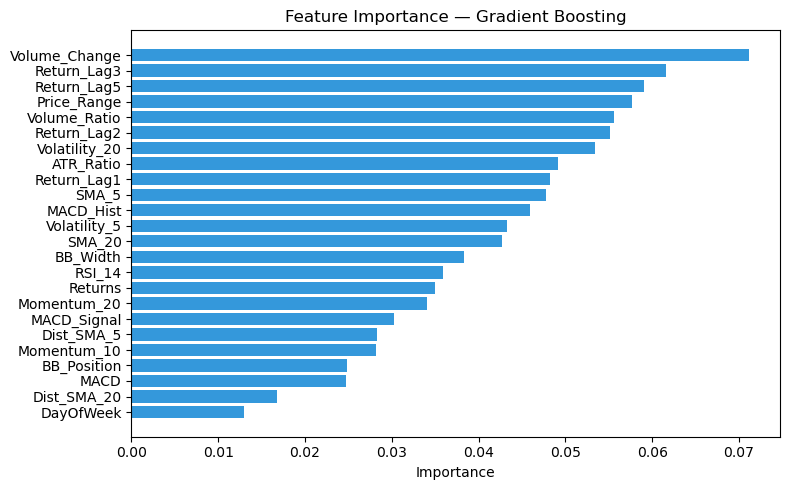

In [51]:
def plot_feature_importance(pipeline, feature_cols, model_name):
    """Plot feature importance."""
    
    clf = pipeline.named_steps.get("clf") or pipeline.estimators_[0][1].named_steps["clf"]
    
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
    elif hasattr(clf, "coef_"):
        importances = np.abs(clf.coef_).mean(axis=0)
    else:
        print("Cannot extract feature importance")
        return
    
    df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=True)
    
    plt.figure(figsize=(8, 5))
    plt.barh(df["Feature"], df["Importance"], color="#3498db")
    plt.xlabel("Importance")
    plt.title(f"Feature Importance — {model_name}")
    plt.tight_layout()
    plt.show()

# Plot for best model (if not ensemble)
if best["type"] != "Ensemble":
    plot_feature_importance(best["pipeline"], FEATURE_COLS, best["name"])

In [52]:
def process_all_tickers(tickers):
    """Run full pipeline for all tickers."""
    
    summary = []
    
    for ticker in tickers:
        print(f"\n{'#'*50}")
        print(f"# {ticker}")
        print(f"{'#'*50}")
        
        try:
            # Load
            X_tr, X_te, y_tr, y_te, _ = load_data(ticker)
            
            # Compare
            comp, trained = compare_models(X_tr, X_te, y_tr, y_te)
            
            # Tune top 2
            top_2 = comp.head(2)["Model"].tolist()
            tuned = {}
            for name in top_2:
                pipe, params, score = tune_model(name, X_tr, y_tr)
                if pipe:
                    tuned[name] = {"pipeline": pipe, "params": params, "cv_score": score}
            
            # Ensemble
            ens, ens_m = create_ensemble(X_tr, y_tr, X_te, y_te)
            
            # Select best
            best = select_and_export(ticker, trained, tuned, ens, ens_m, X_te, y_te)
            
            summary.append({
                "Ticker": ticker,
                "Best Model": best["name"],
                "F1 Macro": round(best["f1"], 4)
            })
            
        except Exception as e:
            print(f"ERROR: {e}")
            summary.append({"Ticker": ticker, "Best Model": "ERROR", "F1 Macro": np.nan})
    
    return pd.DataFrame(summary)

# Run for all
final_summary = process_all_tickers(TICKERS)
final_summary


##################################################
# AMZN
##################################################
Loaded AMZN: 1217 rows
  Train: 851 rows (70%)
  Test:  366 rows (30%)
  Class distribution in train: {0: np.int64(245), 1: np.int64(169), 2: np.int64(178), 3: np.int64(259)}
Training models...
------------------------------------------------------------
Logistic Regression       | Acc: 0.2350 | F1: 0.2346
Random Forest             | Acc: 0.2459 | F1: 0.2302
Gradient Boosting         | Acc: 0.2596 | F1: 0.2554
XGBoost                   | Acc: 0.2432 | F1: 0.2351
------------------------------------------------------------
Tuning Gradient Boosting...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 150}
  Best CV F1:  0.2473

Tuning XGBoost...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimator

,Ticker,Best Model,F1 Macro
0,AMZN,Gradient Boosting,0.2554
1,AAPL,Random Forest,0.2758
2,MSFT,Random Forest (Tuned),0.2724
3,GOOG,Ensemble,0.2406
4,TSLA,Ensemble,0.2560


In [53]:
print("Exported files:")
print("-" * 40)
for ticker in TICKERS:
    model_ok = os.path.exists(f"{MODELS_DIR}/model_{ticker}.joblib")
    feat_ok = os.path.exists(f"{MODELS_DIR}/features_{ticker}.txt")
    status = "✓" if (model_ok and feat_ok) else "✗"
    print(f"{status} {ticker}")

Exported files:
----------------------------------------
✓ AMZN
✓ AAPL
✓ MSFT
✓ GOOG
✓ TSLA


-----

# THE CODE BELOW IS WHEN ONLY LOGISTIC REGRESSION. NOW WE ARE GOING TO COMPARE SEVERAL 

## Step 3 — Correlation heatmap
Look for pairs of features with |r| >= 0.5 — these may be multicollinear.

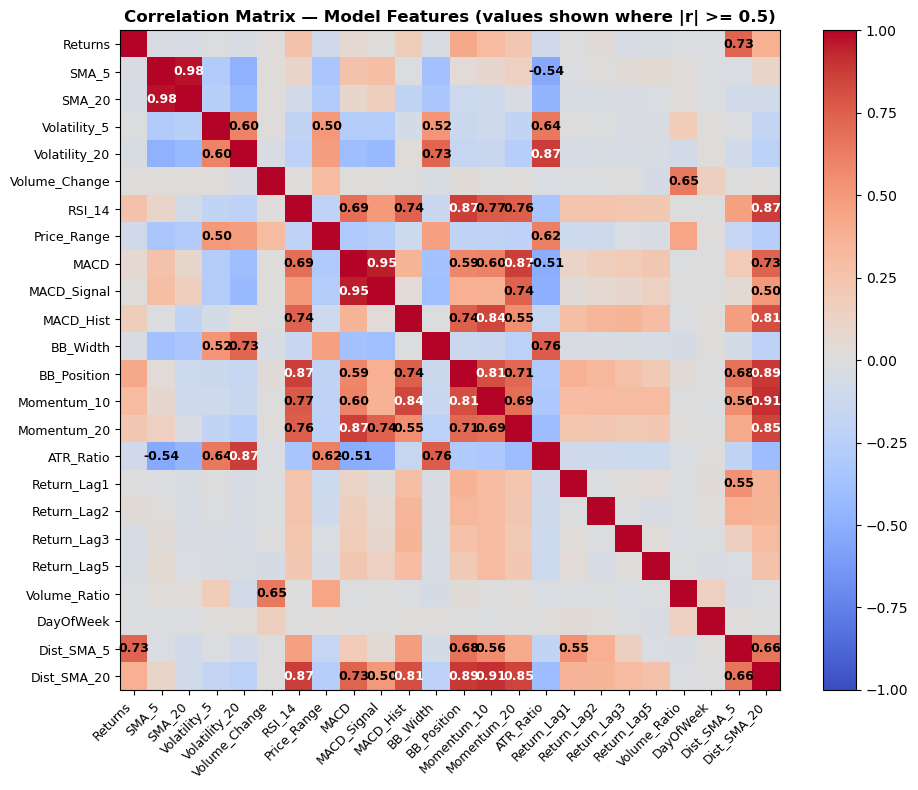

In [54]:
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Annotate only strong correlations
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.5 and i != j:
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if abs(val) > 0.8 else "black",
                    fontsize=9, fontweight="bold")

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=9)
plt.colorbar(cax)
ax.set_title("Correlation Matrix — Model Features (values shown where |r| >= 0.5)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4 — VIF Analysis
Variance Inflation Factor measures multicollinearity.
- VIF > 10 → serious problem, drop that feature
- We drop one at a time (the worst) and recompute until all VIF <= 10

The loop below prints every iteration so you can see exactly what is happening.

In [55]:
def compute_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each feature. Higher = more multicollinear."""
    vif = pd.DataFrame()
    vif["Variable"] = X_df.columns
    vif["VIF"]      = [variance_inflation_factor(X_df.values, i)
                       for i in range(X_df.shape[1])]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)


X_vif     = X_train.copy()
iteration = 1

print("=" * 60)
print("VIF ANALYSIS — drop features with VIF > 10 one at a time")
print("=" * 60)

while True:
    vif_table = compute_vif(X_vif)
    max_vif   = vif_table.iloc[0]["VIF"]
    worst_var = vif_table.iloc[0]["Variable"]

    print(f"\n--- Iteration {iteration} | {X_vif.shape[1]} features remaining ---")
    print(vif_table.to_string(index=False))

    if max_vif <= 10:
        print(f"\n✔  All VIF <= 10 — stopping.")
        print(f"✔  Final feature set: {list(X_vif.columns)}")
        break

    print(f"\n  ⚠  Dropping '{worst_var}'  (VIF = {max_vif:.2f} > 10)")
    X_vif = X_vif.drop(columns=[worst_var])
    iteration += 1

X_after_vif       = X_vif.copy()
selected_vif_cols = X_after_vif.columns.tolist()
print(f"\nFeatures after VIF ({len(selected_vif_cols)}): {selected_vif_cols}")

VIF ANALYSIS — drop features with VIF > 10 one at a time

--- Iteration 1 | 24 features remaining ---
     Variable          VIF
    MACD_Hist          inf
         MACD          inf
  MACD_Signal          inf
        SMA_5 1.158596e+05
       SMA_20 1.154975e+05
   Dist_SMA_5 5.332616e+03
      Returns 2.850940e+03
  Return_Lag1 1.601565e+03
  Return_Lag2 7.088014e+02
  Return_Lag3 1.797654e+02
  Dist_SMA_20 8.333949e+01
    ATR_Ratio 7.477998e+01
       RSI_14 6.746280e+01
Volatility_20 4.154725e+01
  BB_Position 2.912998e+01
 Volume_Ratio 2.744740e+01
  Price_Range 1.364410e+01
     BB_Width 1.136003e+01
  Momentum_10 1.028668e+01
  Momentum_20 9.901257e+00
 Volatility_5 8.323179e+00
    DayOfWeek 3.247191e+00
Volume_Change 1.754867e+00
  Return_Lag5 1.270607e+00

  ⚠  Dropping 'MACD_Hist'  (VIF = inf > 10)

--- Iteration 2 | 23 features remaining ---
     Variable           VIF
        SMA_5 115859.608328
       SMA_20 115497.487961
   Dist_SMA_5   5332.615707
      Returns   2850.

## Step 5 — RFECV Feature Selection
Recursive Feature Elimination with Cross-Validation automatically finds the number of features that maximises AUC.

`TimeSeriesSplit` is used instead of regular KFold because stock data is a time series — shuffling folds would leak future data into training.

In [56]:
# Prepare matrices from VIF-selected columns only
X_train_vif = X_train[selected_vif_cols].dropna()
y_train_vif = y_train.loc[X_train_vif.index]

X_test_vif  = X_test[selected_vif_cols].dropna()
y_test_vif  = y_test.loc[X_test_vif.index]

# Scale on training data only (prevent leakage)
scaler_rfe     = StandardScaler()
X_train_scaled = scaler_rfe.fit_transform(X_train_vif)
X_test_scaled  = scaler_rfe.transform(X_test_vif)

# RFECV
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    step=1,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="roc_auc",
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_train_scaled, y_train_vif)

feature_names     = X_train_vif.columns.tolist()
selected_features = [f for f, s in zip(feature_names, rfecv.support_) if s]
dropped_features  = [f for f, s in zip(feature_names, rfecv.support_) if not s]

print(f"Optimal number of features: {rfecv.n_features_}")
print("\nSelected features:")
for f in selected_features:
    print(f"  ✔  {f}")
print("\nDropped by RFECV:")
for f in dropped_features:
    print(f"  ✗  {f}")

# Plot AUC vs number of features
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"], marker="o", color="#2563EB")
plt.fill_between(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
    rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
    alpha=0.2, color="#2563EB"
)
plt.axvline(rfecv.n_features_, color="red", linestyle="--",
            label=f"Optimal: {rfecv.n_features_} features")
plt.xlabel("Number of Features")
plt.ylabel("Mean CV AUC-ROC")
plt.title("RFECV — Optimal Feature Count (TimeSeriesSplit, 5 folds)")
plt.legend()
plt.tight_layout()
plt.show()

ValueError: multi_class must be in ('ovo', 'ovr')

## Step 6 — Train the Pipeline
A Pipeline chains StandardScaler and LogisticRegression together.
This ensures scaling is always applied consistently when calling predict().

In [ ]:
X_train_sel = X_train[selected_features].dropna()
y_train_sel = y_train.loc[X_train_sel.index]

X_test_sel  = X_test[selected_features].dropna()
y_test_sel  = y_test.loc[X_test_sel.index]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train_sel, y_train_sel)
print(f"Model trained on {len(selected_features)} features: {selected_features}")

Model trained on 3 features: ['Returns', 'Volume_Change', 'Price_Range']


## Step 7 — Confusion Matrix & Classification Report

              precision    recall  f1-score   support

    Fall (0)       0.40      0.28      0.33       207
    Rise (1)       0.49      0.63      0.55       232

    accuracy                           0.46       439
   macro avg       0.45      0.45      0.44       439
weighted avg       0.45      0.46      0.45       439



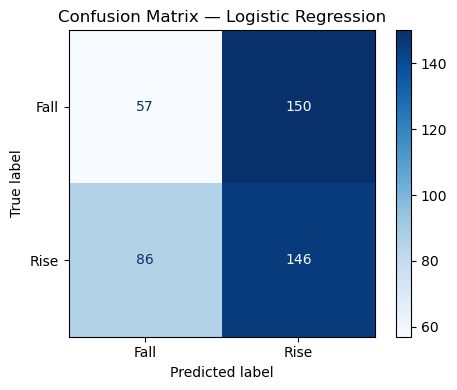

In [ ]:
y_pred = pipe.predict(X_test_sel)

print(classification_report(y_test_sel, y_pred,
      target_names=["Fall (0)", "Rise (1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_sel, y_pred,
    display_labels=["Fall", "Rise"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

## Step 8 — ROC Curve & AUC

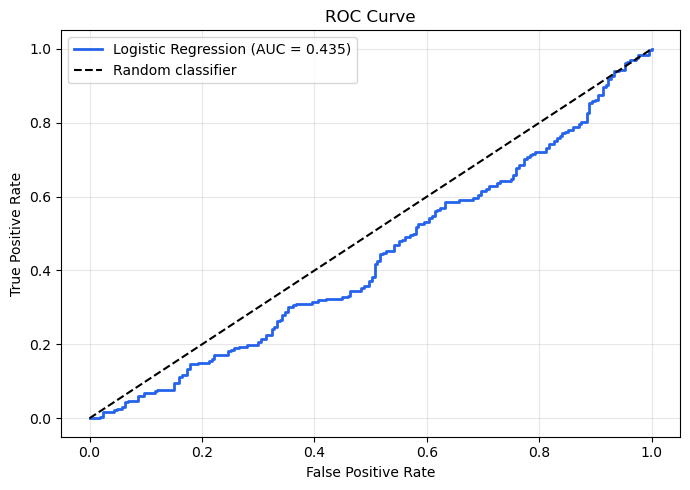

AUC Score: 0.4351


In [ ]:
y_proba = pipe.predict_proba(X_test_sel)[:, 1]
fpr, tpr, _ = roc_curve(y_test_sel, y_proba)
auc = roc_auc_score(y_test_sel, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})",
         color="#2563EB", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

## Step 9 — Threshold Analysis
The default threshold of 0.5 is not always optimal.
Sweep from 0.1 to 0.9 and find the threshold that maximises F1.

 Threshold  Accuracy  Precision  Recall    F1  TP  FP  TN  FN
      0.10     0.528      0.528   1.000 0.692 232 207   0   0
      0.15     0.528      0.528   1.000 0.692 232 207   0   0
      0.20     0.528      0.528   1.000 0.692 232 207   0   0
      0.25     0.528      0.528   1.000 0.692 232 207   0   0
      0.30     0.528      0.528   1.000 0.692 232 207   0   0
      0.35     0.528      0.528   1.000 0.692 232 207   0   0
      0.40     0.528      0.528   1.000 0.692 232 207   0   0
      0.45     0.524      0.527   0.983 0.686 228 205   2   4
      0.50     0.462      0.493   0.629 0.553 146 150  57  86
      0.55     0.456      0.419   0.078 0.131  18  25 182 214
      0.60     0.462      0.167   0.004 0.008   1   5 202 231
      0.65     0.472      0.000   0.000 0.000   0   0 207 232
      0.70     0.472      0.000   0.000 0.000   0   0 207 232
      0.75     0.472      0.000   0.000 0.000   0   0 207 232
      0.80     0.472      0.000   0.000 0.000   0   0 207 232
      0.

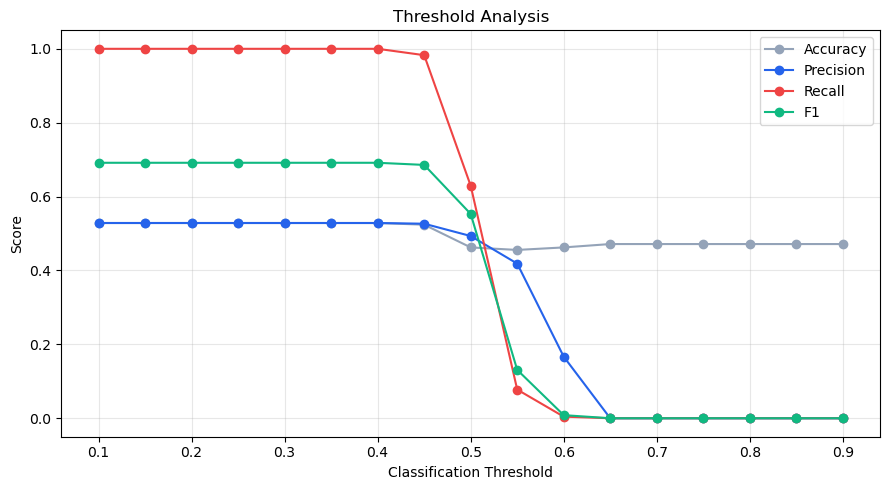


Best threshold by F1: 0.1
Threshold      0.100000
Accuracy       0.528474
Precision      0.528474
Recall         1.000000
F1             0.691505
TP           232.000000
FP           207.000000
TN             0.000000
FN             0.000000
Name: 0, dtype: float64


In [ ]:
results = []
for thr in np.arange(0.1, 0.91, 0.05):
    y_pred_t = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_sel, y_pred_t).ravel()
    results.append({
        "Threshold": round(thr, 2),
        "Accuracy":  accuracy_score(y_test_sel, y_pred_t),
        "Precision": precision_score(y_test_sel, y_pred_t, zero_division=0),
        "Recall":    recall_score(y_test_sel, y_pred_t, zero_division=0),
        "F1":        f1_score(y_test_sel, y_pred_t, zero_division=0),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.round(3).to_string(index=False))

# Plot
plt.figure(figsize=(9, 5))
for metric, color in [("Accuracy","#94a3b8"),("Precision","#2563EB"),
                       ("Recall","#ef4444"),("F1","#10b981")]:
    plt.plot(threshold_df["Threshold"], threshold_df[metric],
             marker="o", label=metric, color=color)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print(f"\nBest threshold by F1: {best_row['Threshold']}")
print(best_row)

## Step 10 — Export the model
Saves the trained pipeline and selected feature list.
The Streamlit web app loads these two files at runtime.

In [ ]:
model_path    = os.path.join(MODELS_DIR, f"model_{TICKER}.joblib")
features_path = os.path.join(MODELS_DIR, f"features_{TICKER}.txt")

joblib.dump(pipe, model_path)

with open(features_path, "w") as f:
    f.write("\n".join(selected_features))

print(f"✔  Model saved    → {model_path}")
print(f"✔  Features saved → {features_path}")

✔  Model saved    → ../my-repo/models/model_AMZN.joblib
✔  Features saved → ../my-repo/models/features_AMZN.txt


## Step 11 — Scale to all tickers
Run the full pipeline for each ticker in one loop.
Make sure the ETL has already been run for all tickers before this cell.

In [ ]:
def train_and_save(ticker: str) -> dict:
    """Full ML pipeline for one ticker. Returns AUC score."""
    df = pd.read_csv(f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv",
                     parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)

    df_model, _ = train_test_split(df, test_size=0.1,
                                   shuffle=False, random_state=42)
    X = df_model[FEATURE_COLS]
    y = df_model[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, shuffle=False, random_state=42)

    # VIF
    X_vif = X_train.dropna().copy()
    while True:
        vif_table = compute_vif(X_vif)
        if vif_table.iloc[0]["VIF"] <= 10:
            break
        X_vif = X_vif.drop(columns=[vif_table.iloc[0]["Variable"]])
    vif_cols = X_vif.columns.tolist()

    # RFECV
    X_tr = X_train[vif_cols].dropna()
    y_tr = y_train.loc[X_tr.index]
    X_te = X_test[vif_cols].dropna()
    y_te = y_test.loc[X_te.index]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    rfe = RFECV(LogisticRegression(max_iter=1000, random_state=42),
                step=1, cv=TimeSeriesSplit(n_splits=5),
                scoring="roc_auc", min_features_to_select=3, n_jobs=-1)
    rfe.fit(X_tr_s, y_tr)
    feats = [f for f, s in zip(vif_cols, rfe.support_) if s]

    # Train pipeline
    pipe_t = Pipeline([("scaler", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=1000, random_state=42))])
    pipe_t.fit(X_tr[feats], y_tr)
    auc = roc_auc_score(y_te, pipe_t.predict_proba(X_te[feats])[:, 1])

    # Save
    joblib.dump(pipe_t, f"{MODELS_DIR}/model_{ticker}.joblib")
    with open(f"{MODELS_DIR}/features_{ticker}.txt", "w") as f:
        f.write("\n".join(feats))

    print(f"{ticker:6s}  AUC = {auc:.3f}  features = {feats}")
    return {"ticker": ticker, "auc": round(auc, 4), "features": feats}


TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]
summary = [train_and_save(t) for t in TICKERS]
pd.DataFrame(summary).set_index("ticker")

AMZN    AUC = 0.435  features = ['Returns', 'Volume_Change', 'Price_Range']
AAPL    AUC = 0.477  features = ['Returns', 'Volatility_5', 'RSI_14', 'Price_Range']
MSFT    AUC = 0.513  features = ['Volatility_5', 'RSI_14', 'Price_Range']
GOOG    AUC = 0.480  features = ['Returns', 'SMA_20', 'Volatility_5', 'Volume_Change', 'RSI_14', 'Price_Range']
TSLA    AUC = 0.580  features = ['Returns', 'SMA_20', 'RSI_14']


,auc,features
ticker,,
AMZN,0.4351,"[Returns, Volume_Change, Price_Range]"
AAPL,0.4767,"[Returns, Volatility_5, RSI_14, Price_Range]"
MSFT,0.5130,"[Volatility_5, RSI_14, Price_Range]"
GOOG,0.4796,"[Returns, SMA_20, Volatility_5, Volume_Change,..."
TSLA,0.5802,"[Returns, SMA_20, RSI_14]"


In [ ]:
import os

os.listdir("../models")

['model_AMZN.joblib',
 'model_AAPL.joblib',
 'features_MSFT.txt',
 'features_AMZN.txt',
 'model_MSFT.joblib',
 '.gitkeep',
 'model_GOOG.joblib',
 'features_AAPL.txt',
 'features_GOOG.txt',
 'model_TSLA.joblib',
 'features_TSLA.txt']

In [ ]:
import joblib
import pandas as pd

ticker = "AAPL"

df = pd.read_csv(f"../data/processed/{ticker.lower()}_processed.csv")

model = joblib.load(f"../my-repo/models/model_{ticker}.joblib")

with open(f"../my-repo/models/features_{ticker}.txt") as f:
    feats = [line.strip() for line in f]

X = df[feats].dropna()

pred = model.predict(X.tail(1))

print("Prediction:", pred)

Prediction: [1.]
